# Compare FAISS Search Methods (Exact vs HNSW vs IVF-PQ vs LSH)

This notebook compares the FAISS search methods benchmarked by
`benchmark_ann.py` on the real ResNet18 Zappos embeddings - the team's
second dataset, using the same protocol as the ViT-COCO benchmark:

```text
1,000 held-out query vectors (seed 42)
        |
49,025 gallery vectors -> Exact FlatIP / HNSW / IVF-PQ / LSH
        |
exact top-20 = ground truth -> Recall@5/10/20 per method
```

It shows:

1. an aggregate metrics table (recall, latency, QPS, build time, index size),
2. recall-vs-latency and recall-vs-size plots plus parameter sweeps,
3. **the same query searched by every method side by side**, with per-result
   hit/miss markers against the exact top-K and UT-Zap50K category labels,
4. category-level retrieval quality per method (Zappos folder labels),
5. a cross-dataset comparison against the ViT-COCO benchmark.

Prerequisites: run `benchmark_ann.py` once (see README.md), and have the
ResNet18 embeddings plus the UT-Zap50K images in place (README steps for
`data/zappos/`).

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Query image ids to visualise in section 2. None = first 3 of the
# 1,000 benchmark queries. Any id printed as "available query ids"
# below can be used.
QUERY_IDS = None

# Which ANN settings to display side by side (file stems from
# results/ann/per_query/, without "_top20.npy"). The full list of
# available settings is printed below - swap freely.
SHOW_SETTINGS = {
    "hnsw_ef128": "HNSW (efSearch=128)",
    "ivfpq_np32": "IVF-PQ (nprobe=32)",
    "lsh_nb512": "LSH (nbits=512)",
}

K_DISPLAY = 10   # results shown per method (recall computed at this K)
SAVE_IMAGES = True

In [2]:
# Resolve the repo root whether the notebook runs from its own folder
# or from the repository root.
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "data" / "zappos").exists():
    REPO_ROOT = REPO_ROOT.parent.parent

EMBEDDINGS_PATH = REPO_ROOT / "data" / "zappos" / "resnet_embeddings.npy"
IDS_PATH = REPO_ROOT / "data" / "zappos" / "resnet_image_ids.npy"
IMAGE_ROOT = REPO_ROOT / "data" / "zappos" / "ut-zap50k-images" / "ut-zap50k-images"
ANN_DIR = REPO_ROOT / "experiments" / "resnet18-zappos" / "results" / "ann"
PER_QUERY_DIR = ANN_DIR / "per_query"
OUTPUT_DIR = ANN_DIR / "visual-comparisons"

data = json.loads((ANN_DIR / "ann_results.json").read_text())
embeddings = np.load(EMBEDDINGS_PATH, mmap_mode="r")
ids = np.load(IDS_PATH)
query_rows = np.load(PER_QUERY_DIR / "query_rows.npy")
gallery_rows = np.load(PER_QUERY_DIR / "gallery_rows.npy")
exact_top20 = np.load(PER_QUERY_DIR / "exact_top20.npy")
query_ids = ids[query_rows]

# Image lookup: UT-Zap50K has no integer ids, so rows are the
# lexicographically sorted image paths (same ordering the teammate's
# extract_features.py used to build the embeddings).
image_paths = sorted(IMAGE_ROOT.rglob("*.jpg"), key=lambda p: str(p))
assert len(image_paths) == len(ids), "image count does not match embedding rows"
categories = np.array([p.relative_to(IMAGE_ROOT).parts[0] for p in image_paths])
subcategories = np.array([p.relative_to(IMAGE_ROOT).parts[1] for p in image_paths])

metadata = data["metadata"]
print("gallery size:", metadata["gallery_size"])
print("queries:", metadata["num_queries"], "| dimension:", metadata["dimension"])
print("ground truth K:", metadata["k_gt"], "| seed:", metadata["seed"])
print()
print("available query image ids (first 30 of", len(query_ids), "):")
print(query_ids[:30].tolist())
print()
print("available ANN settings in per_query/:")
for path in sorted(PER_QUERY_DIR.glob("*_top20.npy")):
    print("  -", path.name.replace("_top20.npy", ""))

gallery size: 49025
queries: 1000 | dimension: 512
ground truth K: 20 | seed: 42

available query image ids (first 30 of 1000 ):
[2, 3, 77, 141, 158, 218, 275, 294, 311, 319, 445, 458, 578, 618, 642, 647, 712, 725, 758, 831, 1003, 1052, 1089, 1102, 1166, 1184, 1257, 1356, 1374, 1440]

available ANN settings in per_query/:
  - exact
  - hnsw_ef128
  - hnsw_ef16
  - hnsw_ef256
  - hnsw_ef32
  - hnsw_ef64
  - ivfpq_np16
  - ivfpq_np1
  - ivfpq_np32
  - ivfpq_np4
  - ivfpq_np64
  - ivfpq_np8
  - lsh_nb256
  - lsh_nb512


## 1. Aggregate comparison

Recall@K = fraction of the exact top-K neighbours that the method also
returns. All searches ran single-threaded; build times used all cores.

In [3]:
def setting_str(row):
    params = row["parameters"]
    algo = row["algorithm"]
    if algo == "HNSW":
        return f"efSearch={params['efSearch']}"
    if algo == "IVF-PQ":
        return f"nprobe={params['nprobe']}"
    if algo == "LSH":
        return f"nbits={params['nbits']}"
    return "-"

rows = data["results"]
header = (
    f"{'Method':<13} {'Setting':<14} {'R@5':>6} {'R@10':>6} {'R@20':>6} "
    f"{'ms/query':>9} {'QPS':>8} {'build(s)':>9} {'size(MB)':>9}"
)
print(header)
print("-" * len(header))
for row in rows:
    print(
        f"{row['algorithm']:<13} {setting_str(row):<14} "
        f"{row['recall_at_5']:>6.3f} {row['recall_at_10']:>6.3f} {row['recall_at_20']:>6.3f} "
        f"{row['latency_ms_per_query']:>9.3f} {row['queries_per_second']:>8.1f} "
        f"{row['build_seconds']:>9.1f} {row['index_size_mb']:>9.1f}"
    )

Method        Setting           R@5   R@10   R@20  ms/query      QPS  build(s)  size(MB)
----------------------------------------------------------------------------------------
Exact FlatIP  -               1.000  1.000  1.000     0.623   1604.3       0.1      95.8
HNSW          efSearch=16     0.945  0.929  0.894     0.109   9163.5       8.3     108.5
HNSW          efSearch=32     0.982  0.976  0.962     0.157   6380.6       8.3     108.5
HNSW          efSearch=64     0.994  0.993  0.989     0.261   3830.4       8.3     108.5
HNSW          efSearch=128    0.999  0.998  0.997     0.451   2217.4       8.3     108.5
HNSW          efSearch=256    1.000  1.000  1.000     0.795   1257.5       8.3     108.5
IVF-PQ        nprobe=1        0.261  0.277  0.293     0.062  16003.5       7.4       2.9
IVF-PQ        nprobe=4        0.321  0.358  0.395     0.077  13034.3       7.4       2.9
IVF-PQ        nprobe=8        0.333  0.369  0.410     0.102   9798.6       7.4       2.9
IVF-PQ        nprobe=

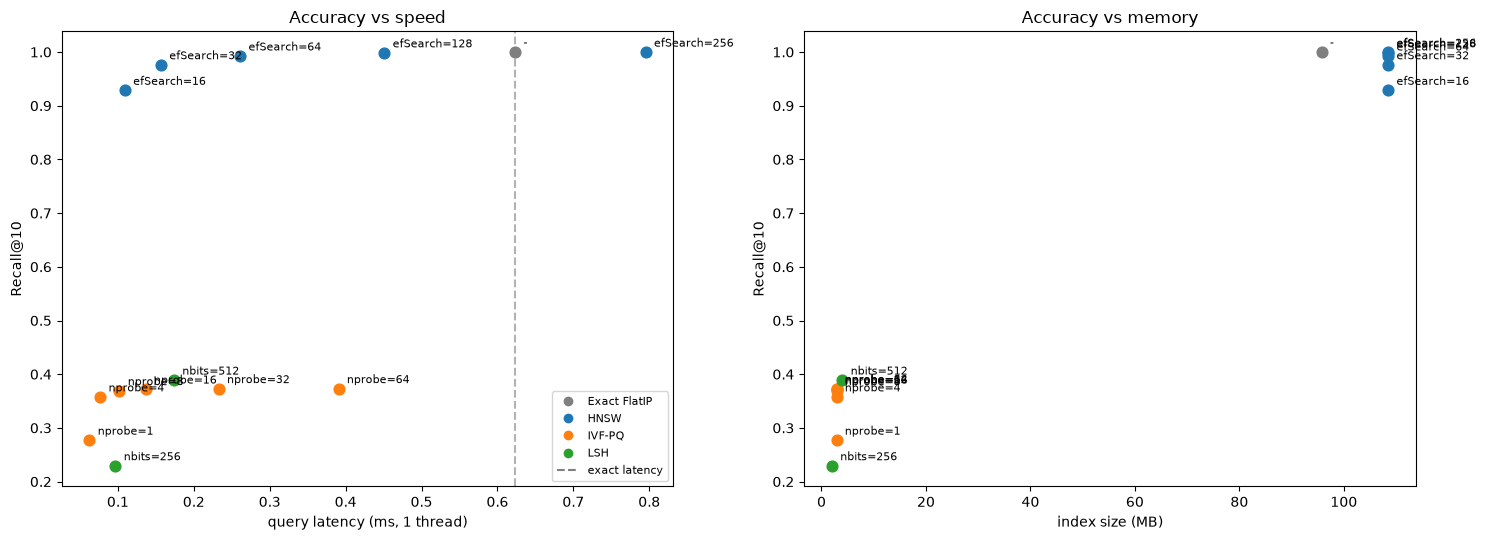

In [4]:
# Left: recall@10 vs latency (speed-accuracy trade-off).
# Right: recall@10 vs index size (memory-accuracy trade-off).
colors = {
    "Exact FlatIP": "tab:gray",
    "HNSW": "tab:blue",
    "IVF-PQ": "tab:orange",
    "LSH": "tab:green",
}
exact_row = next(r for r in rows if r["algorithm"] == "Exact FlatIP")

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for row in rows:
    color = colors[row["algorithm"]]
    axes[0].scatter(row["latency_ms_per_query"], row["recall_at_10"], color=color, s=60)
    axes[0].annotate(
        setting_str(row),
        (row["latency_ms_per_query"], row["recall_at_10"]),
        textcoords="offset points", xytext=(6, 4), fontsize=8,
    )
    axes[1].scatter(row["index_size_mb"], row["recall_at_10"], color=color, s=60)
    axes[1].annotate(
        setting_str(row),
        (row["index_size_mb"], row["recall_at_10"]),
        textcoords="offset points", xytext=(6, 4), fontsize=8,
    )

axes[0].axvline(exact_row["latency_ms_per_query"], color="tab:gray",
                linestyle="--", alpha=0.6, label="exact latency")
axes[0].set_xlabel("query latency (ms, 1 thread)")
axes[0].set_ylabel("Recall@10")
axes[0].set_title("Accuracy vs speed")
axes[0].legend(handles=[plt.Line2D([], [], marker="o", linestyle="", color=c, label=a)
                        for a, c in colors.items()] + [plt.Line2D([], [], color="tab:gray", linestyle="--", label="exact latency")],
                fontsize=8)
axes[1].set_xlabel("index size (MB)")
axes[1].set_ylabel("Recall@10")
axes[1].set_title("Accuracy vs memory")
plt.tight_layout()
plt.show()

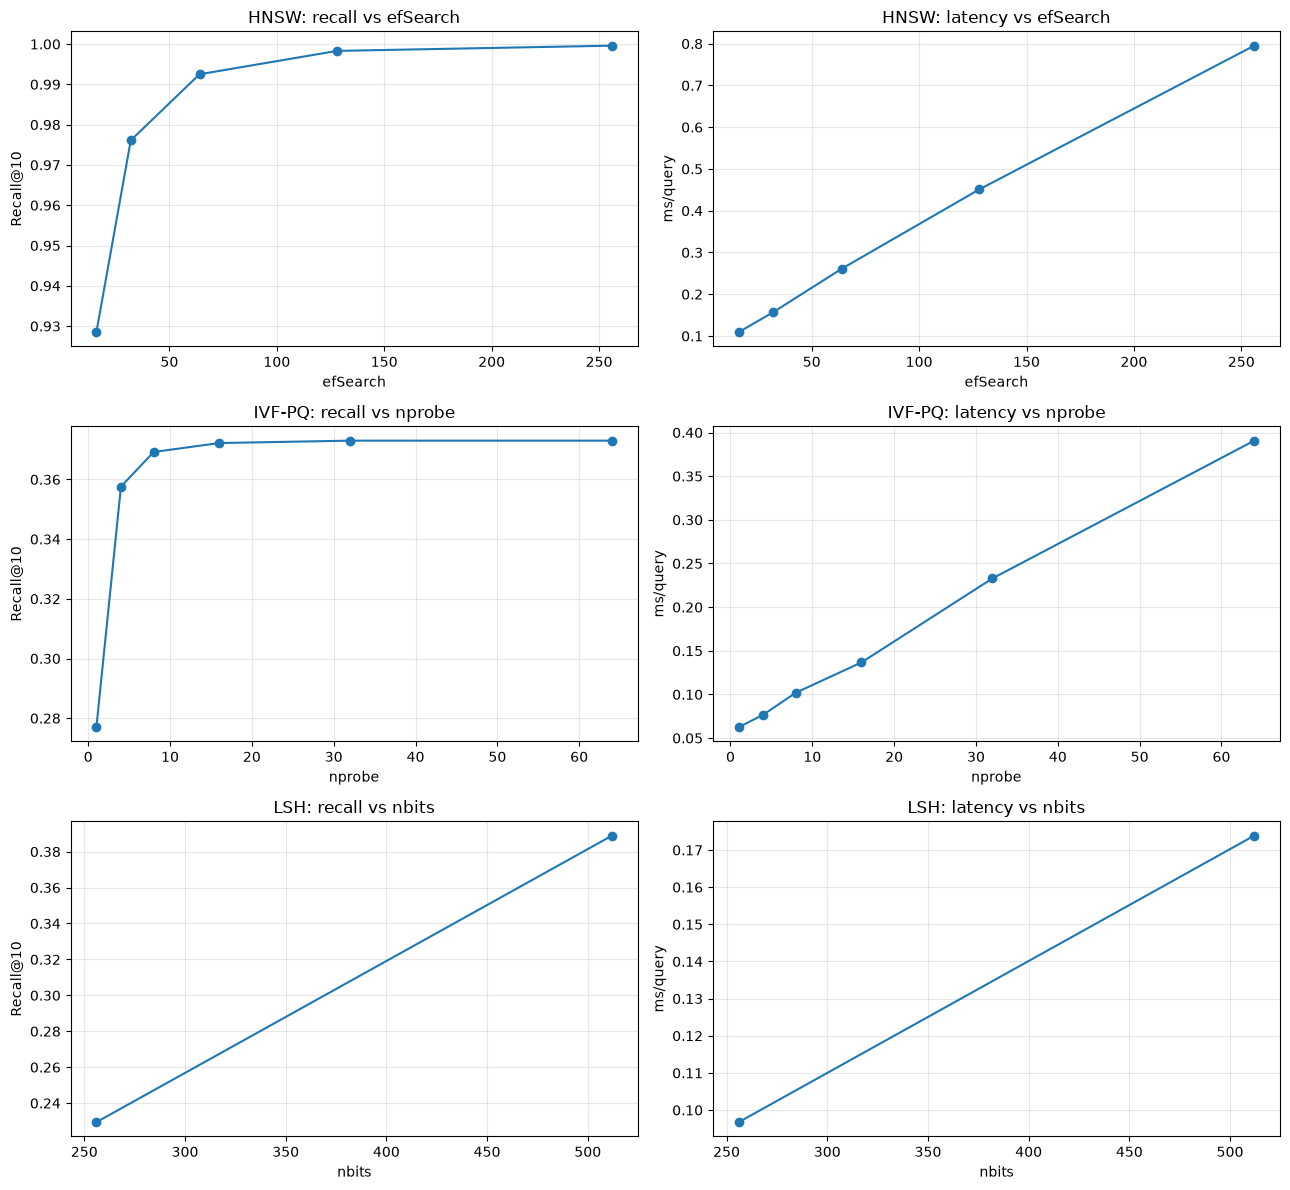

In [5]:
# Parameter sweeps: recall@10 and latency vs the swept parameter.
sweep_specs = [
    ("HNSW", "efSearch"),
    ("IVF-PQ", "nprobe"),
    ("LSH", "nbits"),
]
fig, axes = plt.subplots(len(sweep_specs), 2, figsize=(13, 4 * len(sweep_specs)))
for i, (algo, param) in enumerate(sweep_specs):
    sub = [r for r in rows if r["algorithm"] == algo]
    x = [r["parameters"][param] for r in sub]
    axes[i][0].plot(x, [r["recall_at_10"] for r in sub], "o-")
    axes[i][0].set_xlabel(param)
    axes[i][0].set_ylabel("Recall@10")
    axes[i][0].set_title(f"{algo}: recall vs {param}")
    axes[i][0].grid(alpha=0.3)
    axes[i][1].plot(x, [r["latency_ms_per_query"] for r in sub], "o-")
    axes[i][1].set_xlabel(param)
    axes[i][1].set_ylabel("ms/query")
    axes[i][1].set_title(f"{algo}: latency vs {param}")
    axes[i][1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Same query, different methods

One row per method, all searching the **same query** (first column).
Each result is labelled `#rank OK/MISS category/subcategory id cosine`.
**MISS** (red) means the exact top-10 also contains that neighbour but this
method ranked something else there instead - i.e. a retrieval error. The
row label shows the method's per-query Recall@10.

In [6]:
def top_k(setting_key, k):
    arr = np.load(PER_QUERY_DIR / f"{setting_key}_top20.npy")
    return arr[:, :k]

def query_position(query_id):
    matches = np.where(query_ids == int(query_id))[0]
    return int(matches[0]) if len(matches) else None

def to_image_id(gallery_row):
    # gallery row -> original embedding row -> image id (== sorted row)
    return int(ids[gallery_rows[int(gallery_row)]])

def exact_id_set(position, k):
    return {to_image_id(row) for row in exact_top20[position, :k]}

def per_query_recall(setting_key, position, k):
    found = {to_image_id(row) for row in top_k(setting_key, k)[position] if row >= 0}
    return len(found & exact_id_set(position, k)) / k

if QUERY_IDS is None:
    QUERY_IDS = query_ids[:3].tolist()

saved: experiments/resnet18-zappos/results/ann/visual-comparisons/query_2_methods.png


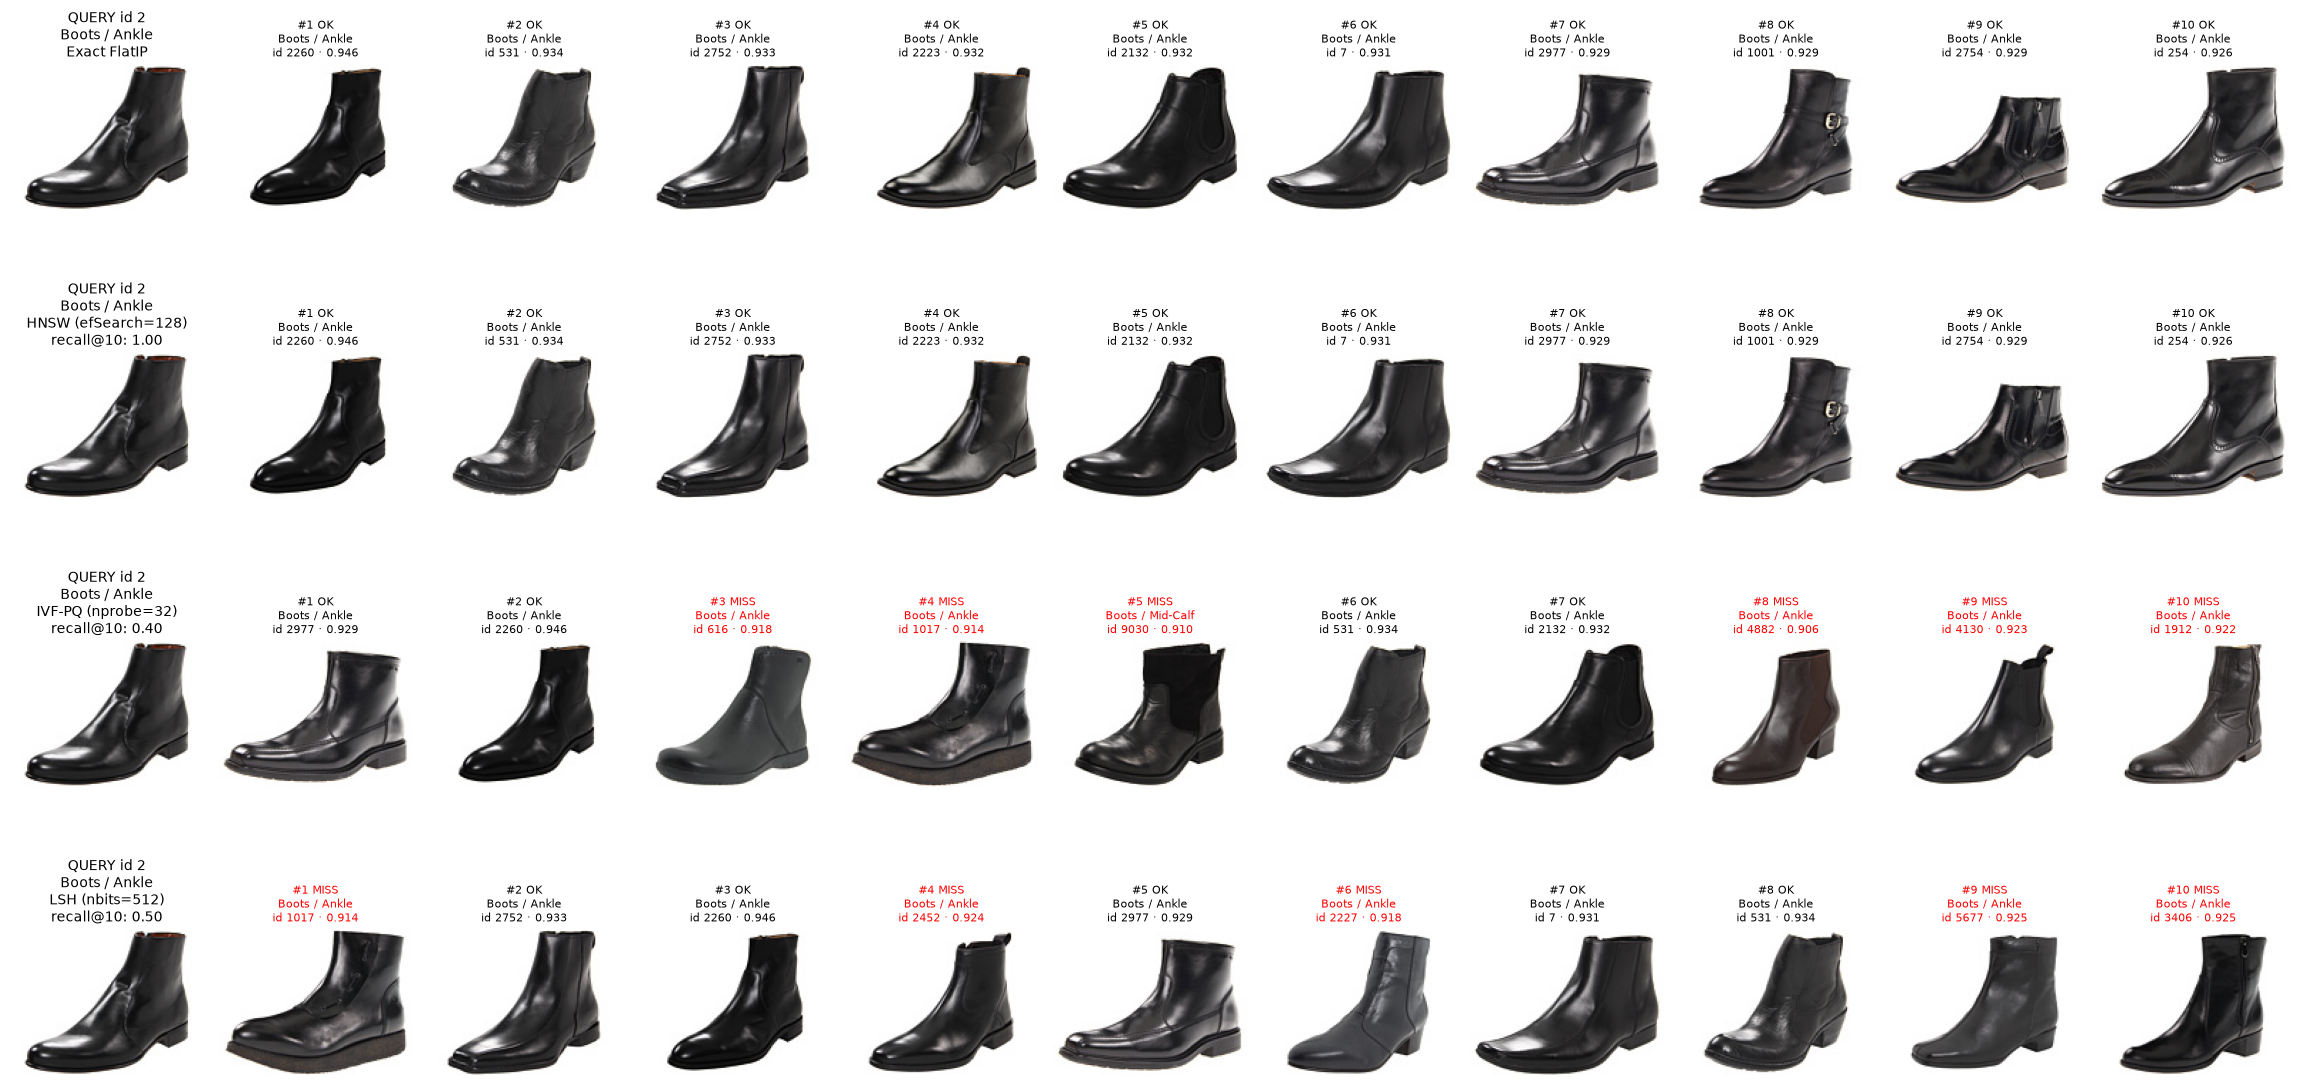

saved: experiments/resnet18-zappos/results/ann/visual-comparisons/query_3_methods.png


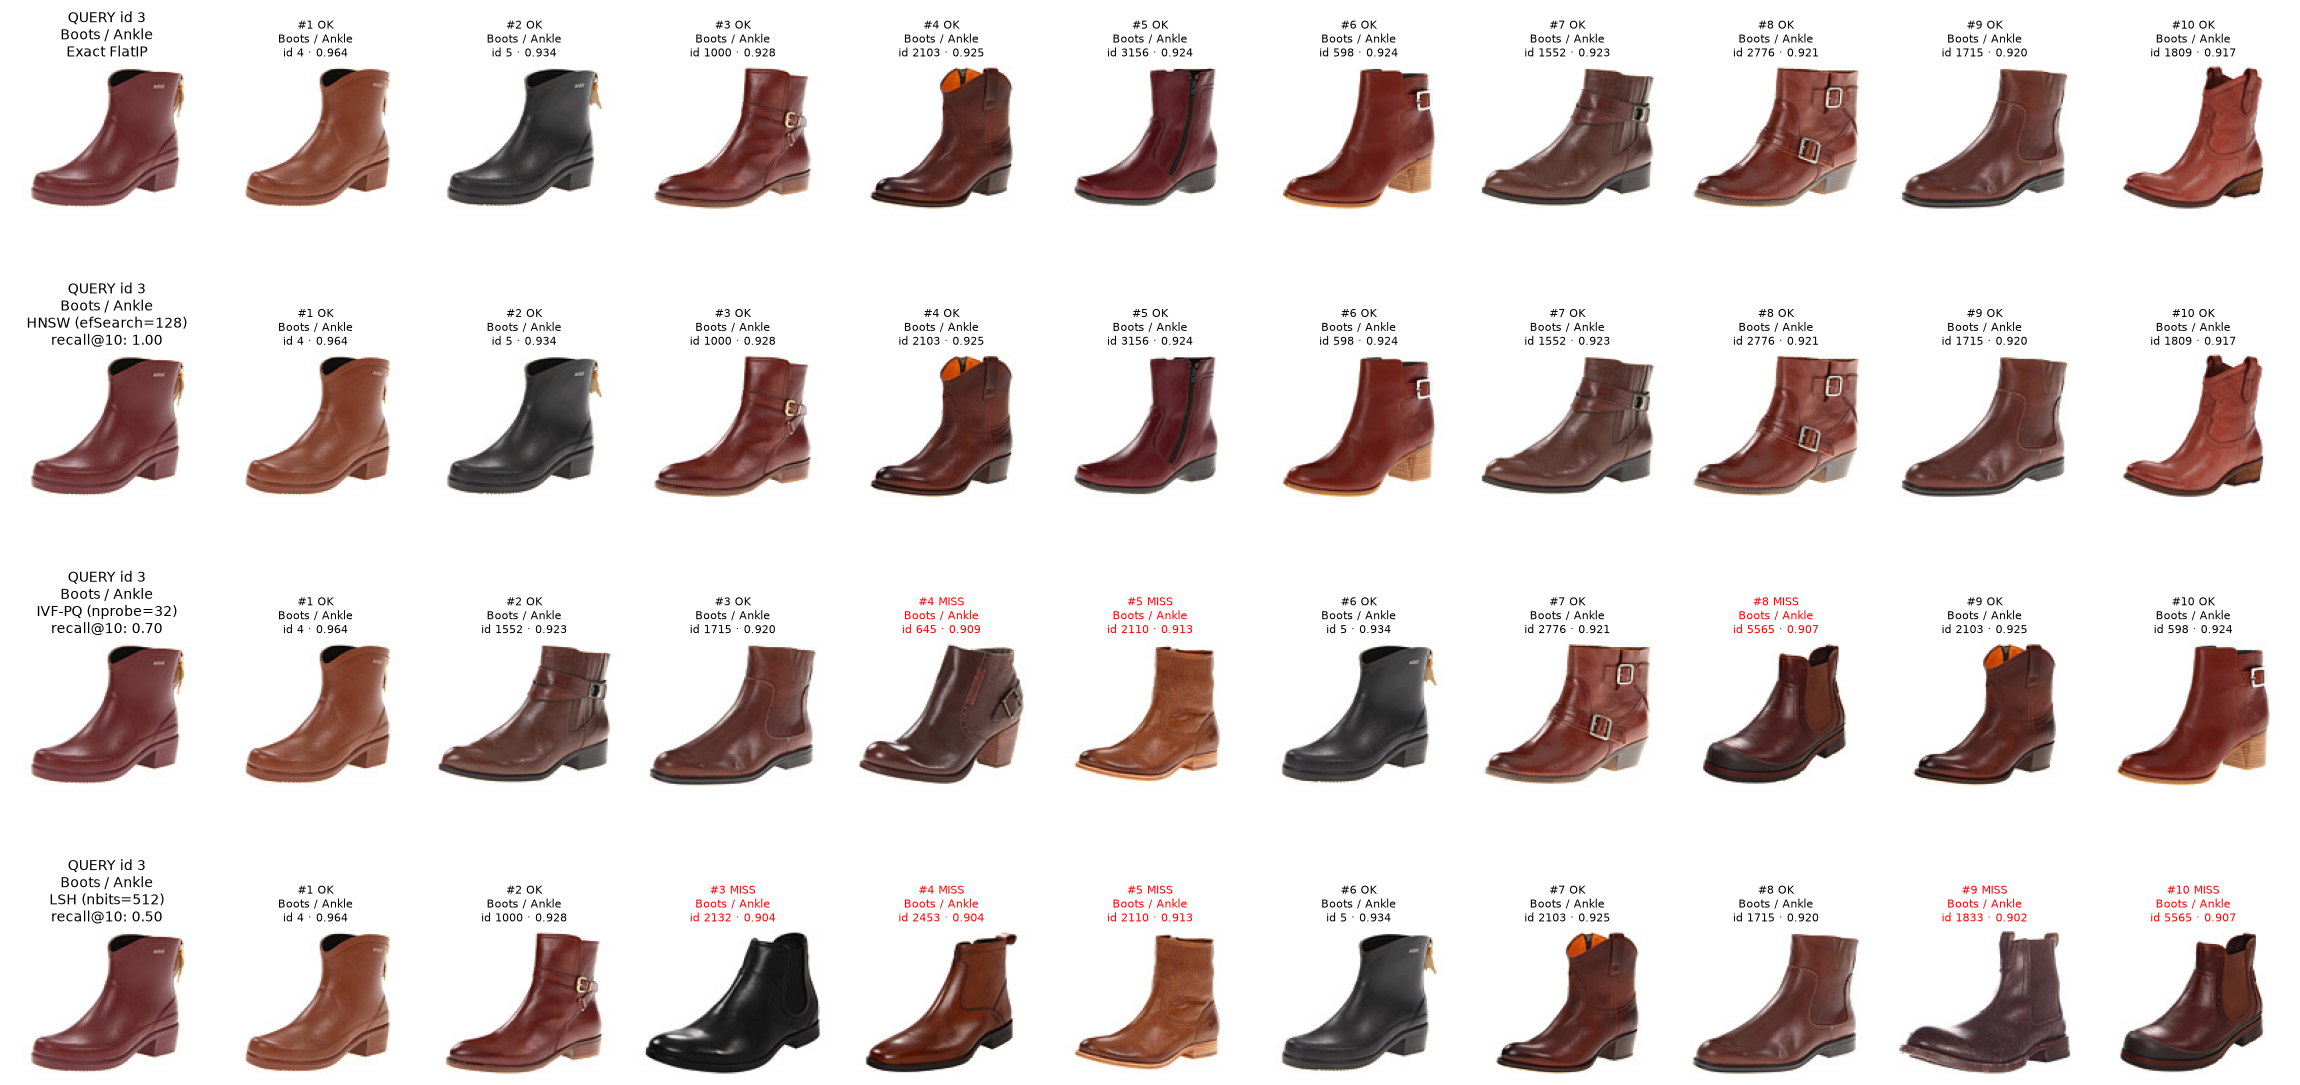

saved: experiments/resnet18-zappos/results/ann/visual-comparisons/query_77_methods.png


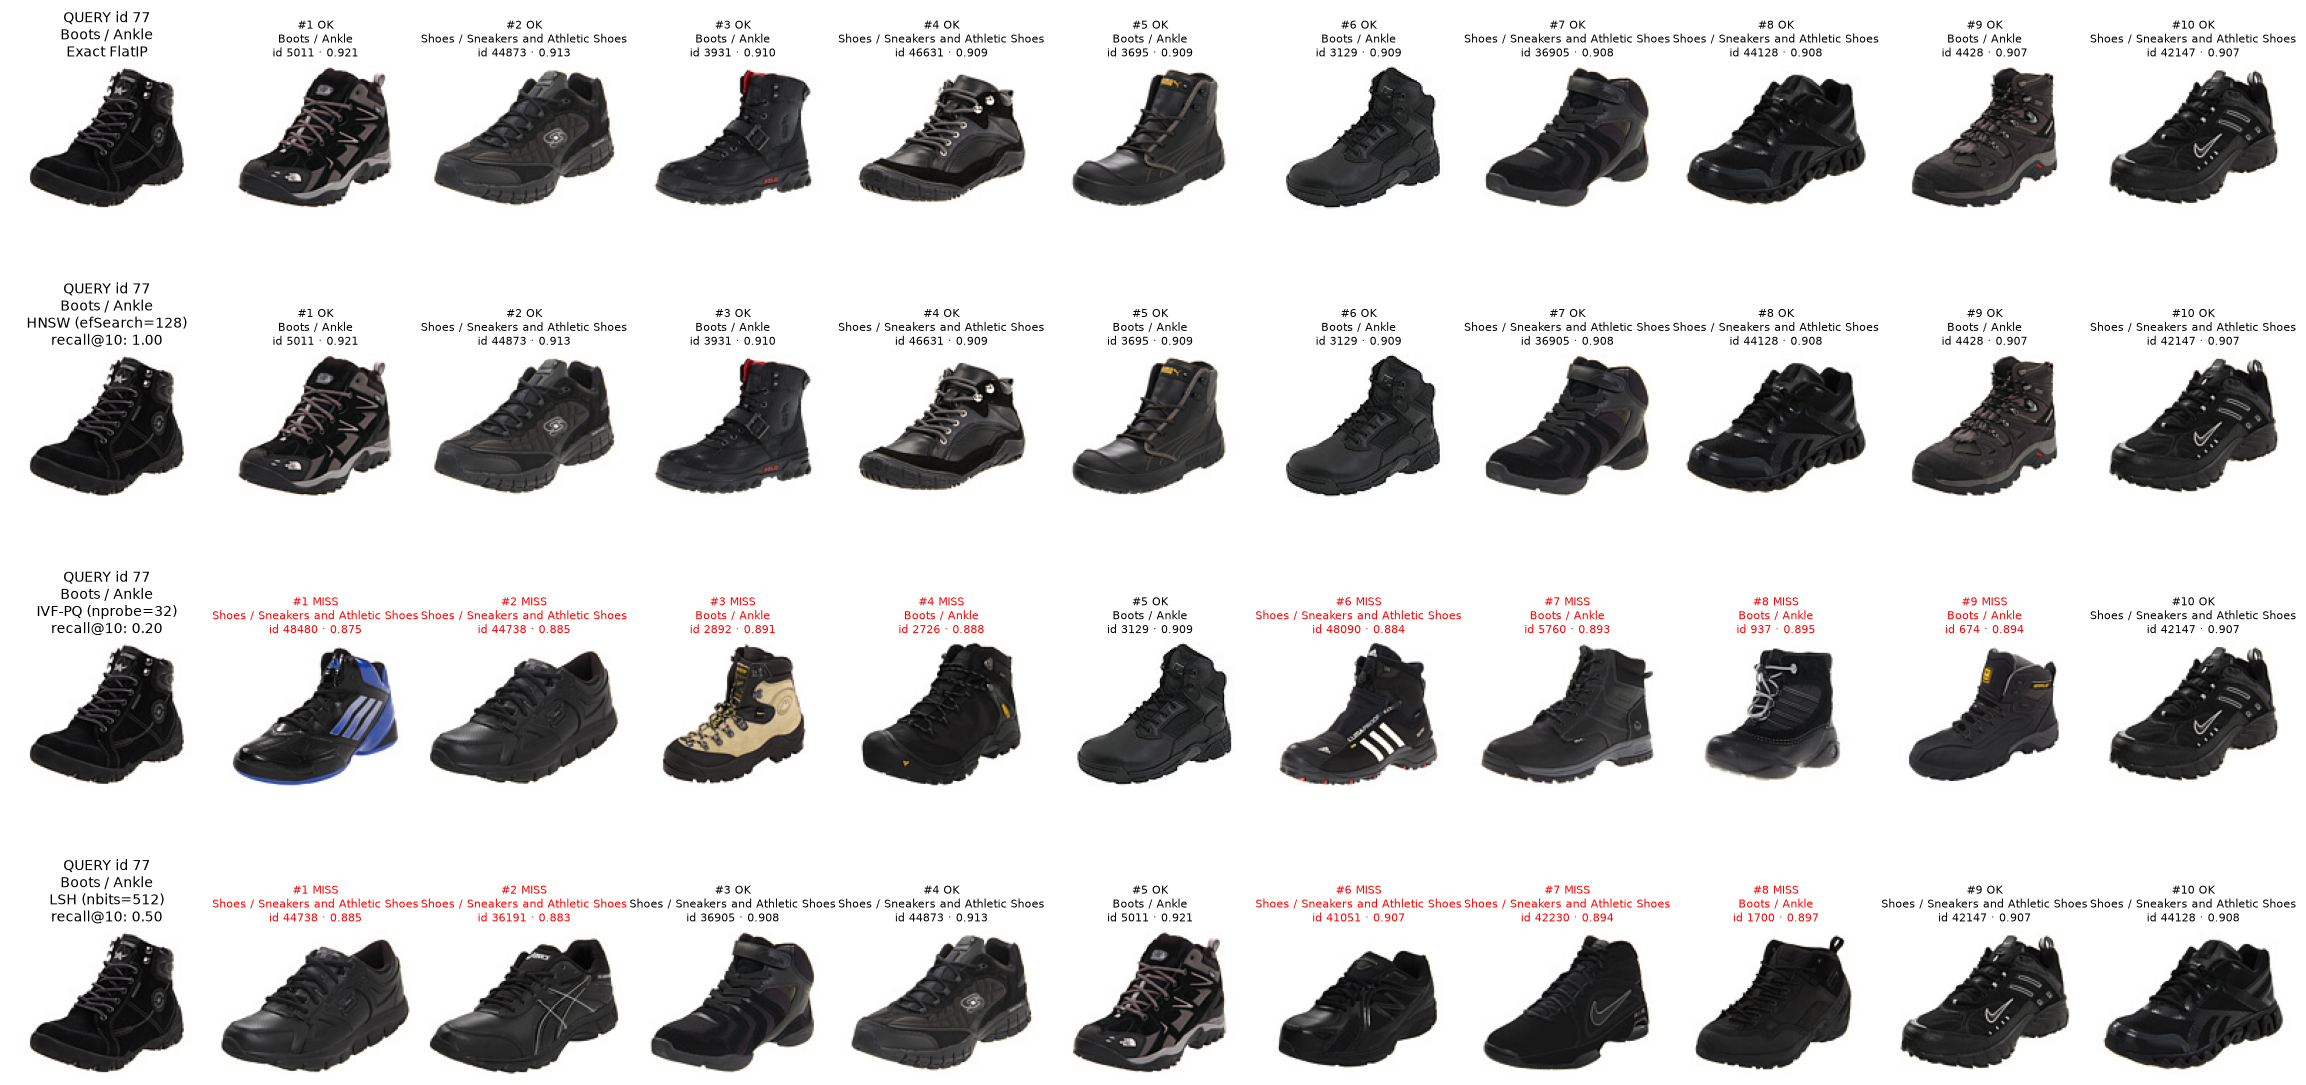

In [7]:
def compare_query(query_id):
    position = query_position(query_id)
    if position is None:
        print(f"query {query_id} is not in the benchmark query set - pick an id from the list above")
        return

    query_row = int(query_rows[position])
    query_vector = np.asarray(embeddings[query_row])
    query_image = Image.open(image_paths[query_id]).convert("RGB")
    query_label = f"{categories[query_id]} / {subcategories[query_id]}"
    reference = exact_id_set(position, K_DISPLAY)

    method_list = [("exact", "Exact FlatIP")] + list(SHOW_SETTINGS.items())
    fig, axes = plt.subplots(
        len(method_list), K_DISPLAY + 1,
        figsize=(2.1 * (K_DISPLAY + 1), 3.0 * len(method_list)),
    )

    for r, (key, label) in enumerate(method_list):
        # First column: the shared query image, labelled with the method.
        if key == "exact":
            title = f"QUERY id {query_id}\n{query_label}\n{label}"
        else:
            recall = per_query_recall(key, position, K_DISPLAY)
            title = f"QUERY id {query_id}\n{query_label}\n{label}\nrecall@{K_DISPLAY}: {recall:.2f}"
        axes[r][0].imshow(query_image)
        axes[r][0].set_title(title, fontsize=10)
        axes[r][0].axis("off")

        result_rows = (
            exact_top20[position, :K_DISPLAY] if key == "exact"
            else top_k(key, K_DISPLAY)[position]
        )

        for c, gallery_row in enumerate(result_rows, start=1):
            ax = axes[r][c]
            if gallery_row < 0:
                # FAISS pads with -1 when fewer than K results exist.
                ax.set_facecolor("lightgray")
                ax.set_title("not\nreturned", fontsize=8)
                ax.set_xticks([]); ax.set_yticks([])
                continue
            result_id = to_image_id(gallery_row)
            result_vector = np.asarray(embeddings[int(gallery_rows[gallery_row])])
            score = float(result_vector @ query_vector)  # cosine (normalized)
            hit = result_id in reference
            cat_label = f"{categories[result_id]} / {subcategories[result_id]}"
            ax.imshow(Image.open(image_paths[result_id]).convert("RGB"))
            ax.set_title(
                f"#{c} {'OK' if hit else 'MISS'}\n{cat_label}\nid {result_id} · {score:.3f}",
                fontsize=8, color="black" if hit else "red",
            )
            ax.axis("off")

    plt.tight_layout()
    if SAVE_IMAGES:
        OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        out_path = OUTPUT_DIR / f"query_{query_id}_methods.png"
        plt.savefig(out_path, dpi=120, bbox_inches="tight")
        print("saved:", out_path.relative_to(REPO_ROOT))
    plt.show()

for query_id in QUERY_IDS:
    compare_query(query_id)

### Per-query recall across every setting

Recall@10 of each benchmarked setting for the queries visualised above.

In [8]:
all_settings = [
    p.name.replace("_top20.npy", "")
    for p in sorted(PER_QUERY_DIR.glob("*_top20.npy"))
    if p.name != "exact_top20.npy"
]

columns = ["exact"] + all_settings
print(f"{'query id':<10}" + "".join(f"{c:>12}" for c in columns))
for query_id in QUERY_IDS:
    position = query_position(query_id)
    if position is None:
        continue
    values = [1.0]  # exact is the reference: recall = 1 by definition
    for key in all_settings:
        values.append(per_query_recall(key, position, K_DISPLAY))
    print(f"{query_id:<10}" + "".join(f"{v:>12.2f}" for v in values))

query id         exact  hnsw_ef128   hnsw_ef16  hnsw_ef256   hnsw_ef32   hnsw_ef64  ivfpq_np16   ivfpq_np1  ivfpq_np32   ivfpq_np4  ivfpq_np64   ivfpq_np8   lsh_nb256   lsh_nb512
2                 1.00        1.00        1.00        1.00        1.00        1.00        0.40        0.40        0.40        0.40        0.40        0.40        0.10        0.50
3                 1.00        1.00        1.00        1.00        1.00        1.00        0.70        0.70        0.70        0.70        0.70        0.70        0.50        0.50
77                1.00        1.00        0.90        1.00        1.00        1.00        0.20        0.00        0.20        0.20        0.20        0.20        0.10        0.50


## 3. Category-level retrieval quality

UT-Zap50K images carry labels from their folder structure
(`Boots / Sandals / Shoes / Slippers` and subcategories). Beyond
vector-space recall, this measures how many of a method's top-10 results
are **the same category as the query** - the label metric the earlier
`evaluate.py` used, now computed for every method, not just exact search.

Category precision is averaged over all 1,000 benchmark queries. The exact
row is the upper bound an ANN method can approximate.

In [9]:
def category_precision(setting_key, k=10):
    if setting_key == "exact":
        result_rows = exact_top20[:, :k]
    else:
        result_rows = np.load(PER_QUERY_DIR / f"{setting_key}_top20.npy")[:, :k]
    query_cats = categories[query_rows][:, None]
    result_cats = categories[gallery_rows[result_rows]]
    return float((result_cats == query_cats)[result_rows >= 0].mean())

def label_for(setting_key):
    row = next(
        r for r in rows
        if r["algorithm"] != "Exact FlatIP"
        and (
            (r["algorithm"] == "HNSW" and f"ef{r['parameters']['efSearch']}" == setting_key.split("hnsw_")[-1])
            or (r["algorithm"] == "IVF-PQ" and f"np{r['parameters']['nprobe']}" == setting_key.split("ivfpq_")[-1])
            or (r["algorithm"] == "LSH" and f"nb{r['parameters']['nbits']}" == setting_key.split("lsh_")[-1])
        )
    )
    return f"{row['algorithm']} {setting_str(row)}"

print(f"{'setting':<24}{'recall@10':>10}{'category P@10':>15}")
print("-" * 49)
print(f"{'Exact FlatIP':<24}{'1.000':>10}{category_precision('exact'):>15.3f}")
for setting_key in all_settings:
    row = next(
        r for r in rows
        if r["algorithm"] != "Exact FlatIP"
        and (
            (r["algorithm"] == "HNSW" and f"hnsw_ef{r['parameters']['efSearch']}" == setting_key)
            or (r["algorithm"] == "IVF-PQ" and f"ivfpq_np{r['parameters']['nprobe']}" == setting_key)
            or (r["algorithm"] == "LSH" and f"lsh_nb{r['parameters']['nbits']}" == setting_key)
        )
    )
    print(
        f"{label_for(setting_key):<24}"
        f"{row['recall_at_10']:>10.3f}"
        f"{category_precision(setting_key):>15.3f}"
    )

setting                  recall@10  category P@10
-------------------------------------------------
Exact FlatIP                 1.000          0.901
HNSW efSearch=128            0.998          0.900
HNSW efSearch=16             0.929          0.899
HNSW efSearch=256            1.000          0.900
HNSW efSearch=32             0.976          0.900
HNSW efSearch=64             0.993          0.900
IVF-PQ nprobe=16             0.372          0.878
IVF-PQ nprobe=1              0.277          0.869
IVF-PQ nprobe=32             0.373          0.879
IVF-PQ nprobe=4              0.358          0.877
IVF-PQ nprobe=64             0.373          0.879
IVF-PQ nprobe=8              0.369          0.878
LSH nbits=256                0.229          0.833
LSH nbits=512                0.389          0.870


## 4. Cross-dataset comparison: ViT-COCO vs ResNet18-Zappos

The same benchmark protocol applied to the team's two datasets.
Caveat: the numbers are **not** directly comparable row-by-row - the
datasets differ in gallery size (122,403 vs 49,025), dimensionality
(768-d ViT vs 512-d ResNet18) and embedding quality. Both benchmarks ran
single-threaded on the same 12-core machine.

ViT-COCO : gallery 122,403 | 768-d
ResNet-Zappos: gallery 49,025 | 512-d

                        --- ViT-COCO --- |  --- ResNet-Zappos ---
setting              R@10    ms/q     MB |    R@10    ms/q     MB
-----------------------------------------------------------------
Exact FlatIP        1.000   2.158  358.6 |   1.000   0.623   95.8
HNSW efSearch=16    0.915   0.149  390.4 |   0.929   0.109  108.5
HNSW efSearch=64    0.986   0.379  390.4 |   0.993   0.261  108.5
HNSW efSearch=128   0.995   0.704  390.4 |   0.998   0.451  108.5
IVF-PQ nprobe=32    0.465   0.536    8.0 |   0.373   0.233    2.9
LSH nbits=512       0.473   0.391    9.0 |   0.389   0.174    4.0


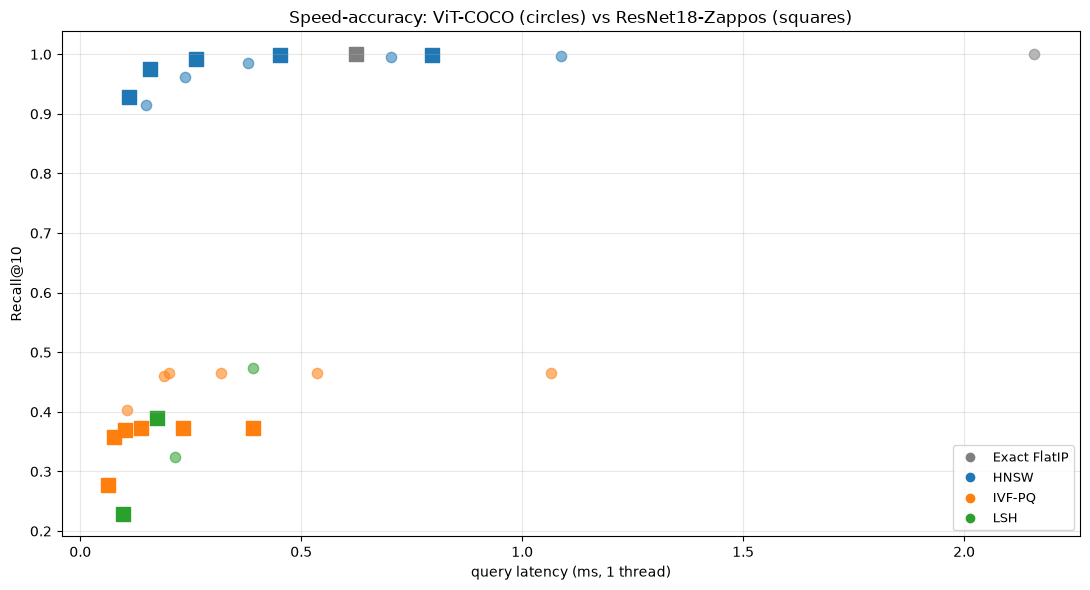

In [10]:
VIT_RESULTS_PATH = (
    REPO_ROOT / "experiments" / "vit-coco-faiss" / "results" / "ann" / "ann_results.json"
)

def pick(results, algo, **params):
    for r in results:
        if r["algorithm"] == algo and all(
            r["parameters"].get(k) == v for k, v in params.items()
        ):
            return r
    return None

vit_data = json.loads(VIT_RESULTS_PATH.read_text())
vit_rows = vit_data["results"]
vit_meta = vit_data["metadata"]

picks = [
    ("Exact FlatIP", "Exact FlatIP", {}),
    ("HNSW efSearch=16", "HNSW", {"efSearch": 16}),
    ("HNSW efSearch=64", "HNSW", {"efSearch": 64}),
    ("HNSW efSearch=128", "HNSW", {"efSearch": 128}),
    ("IVF-PQ nprobe=32", "IVF-PQ", {"nprobe": 32}),
    ("LSH nbits=512", "LSH", {"nbits": 512}),
]

print(f"ViT-COCO : gallery {vit_meta['gallery_size']:,} | {vit_meta['dimension']}-d")
print(f"ResNet-Zappos: gallery {metadata['gallery_size']:,} | {metadata['dimension']}-d")
print()
header = (
    f"{'setting':<18}{'R@10':>7}{'ms/q':>8}{'MB':>7}"
    f" | {'R@10':>7}{'ms/q':>8}{'MB':>7}"
)
print(f"{'':<18}{'--- ViT-COCO ---':>22} | {'--- ResNet-Zappos ---':>22}")
print(header)
print("-" * len(header))
for label, algo, params in picks:
    a = pick(vit_rows, algo, **params)
    b = pick(rows, algo, **params)
    print(
        f"{label:<18}"
        f"{a['recall_at_10']:>7.3f}{a['latency_ms_per_query']:>8.3f}{a['index_size_mb']:>7.1f}"
        f" | "
        f"{b['recall_at_10']:>7.3f}{b['latency_ms_per_query']:>8.3f}{b['index_size_mb']:>7.1f}"
    )

fig, ax = plt.subplots(figsize=(11, 6))
for r in vit_rows:
    ax.scatter(r["latency_ms_per_query"], r["recall_at_10"],
               color=colors[r["algorithm"]], s=55, marker="o", alpha=0.55)
for r in rows:
    ax.scatter(r["latency_ms_per_query"], r["recall_at_10"],
               color=colors[r["algorithm"]], s=90, marker="s")
ax.set_xlabel("query latency (ms, 1 thread)")
ax.set_ylabel("Recall@10")
ax.set_title("Speed-accuracy: ViT-COCO (circles) vs ResNet18-Zappos (squares)")
ax.legend(handles=[plt.Line2D([], [], marker="o", linestyle="", color=c, label=a)
                   for a, c in colors.items()], fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Sanity checks

In [11]:
num_queries = metadata["num_queries"]
k_gt = metadata["k_gt"]
gallery_size = metadata["gallery_size"]

for path in sorted(PER_QUERY_DIR.glob("*_top20.npy")):
    arr = np.load(path)
    assert arr.shape == (num_queries, k_gt), f"bad shape in {path.name}: {arr.shape}"
    assert arr.min() >= -1 and arr.max() < gallery_size, f"out-of-range rows in {path.name}"

exact_metrics = next(r for r in rows if r["algorithm"] == "Exact FlatIP")
assert abs(exact_metrics["recall_at_10"] - 1.0) < 1e-9, "exact recall@10 must be 1.0"

# Held-out split: a query image must never appear in its own results.
for position in range(num_queries):
    query_id = int(query_ids[position])
    result_ids = {to_image_id(row) for row in exact_top20[position] if row >= 0}
    assert query_id not in result_ids, f"query {query_id} leaked into gallery"

print("ALL CHECKS PASSED")
print("- every per-query file has shape", (num_queries, k_gt))
print("- exact baseline recall@10 = 1.0")
print("- no query image appears in its own results (held-out split verified)")

ALL CHECKS PASSED
- every per-query file has shape (1000, 20)
- exact baseline recall@10 = 1.0
- no query image appears in its own results (held-out split verified)


## How to adjust

- **Other queries**: set `QUERY_IDS` in the config cell to any id from the
  "available query image ids" list, then re-run the cells.
- **Other settings side by side**: replace keys in `SHOW_SETTINGS` with any
  setting listed under "available ANN settings" (e.g. `"hnsw_ef256"`),
  then re-run section 2.
- **More displayed results**: raise `K_DISPLAY` (up to 20, the saved
  ground-truth depth).
- The notebook only reads the benchmark outputs; re-running it never
  recomputes FAISS or ResNet18.